# Math 189 Final Project
# Exploratory Data Analysis (EDA)

## Project Goal

This project investigates the relationship between transportation noise exposure and socioeconomic conditions in San Diego County.

The analysis combines:

- Transportation noise data
- Housing value data
- ACS demographic data
- ACS socioeconomic data

All datasets have been merged into a single ZCTA-level master dataset.

The purpose of this notebook is to:

1. Understand the structure of the final dataset
2. Examine missing values
3. Explore variable distributions
4. Investigate relationships between noise and socioeconomic indicators
5. Identify variables that may be useful for modeling

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

master = pd.read_csv("../data/processed/master_dataset.csv")

print("Dataset Shape:")
print(master.shape)

master.head()

Dataset Shape:
(154, 17)


,zcta,noise_mean_db,noise_max_db,noise_min_db,median_household_income,unemployment_rate,population,pnhwhite,pnhblack,phispanic,pforeign_born,punemployed,affluence,disadvantage,median_family_income,home_value,poverty_rate
0,91901,57.659220,80.190165,45.006918,114167.0,56.5,18669.0,0.734426,0.013338,0.183245,0.080401,0.063387,0.382225,0.089527,120444.0,9.732317e+05,10.2
1,91902,54.664245,71.750261,45.571662,122524.0,56.9,17121.0,0.358741,0.019567,0.452953,0.208808,0.076388,0.493448,0.054352,149287.0,1.151980e+06,5.6
2,91903,58.401917,80.374268,45.002365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,91910,55.273382,74.431252,45.067791,90222.0,58.6,76313.0,0.201106,0.035236,0.634034,0.288719,0.095149,0.327853,0.141723,93358.0,8.368809e+05,8.4
4,91911,55.898695,74.625658,45.040166,82350.0,56.5,87799.0,0.121710,0.034727,0.728266,0.318090,0.115322,0.264753,0.150156,87590.0,7.713433e+05,8.9


## 1. Dataset Overview

In this section, we examine:

- Number of observations
- Number of variables
- Data types
- Summary statistics

In [4]:
master.info()

<class 'pandas.DataFrame'>
RangeIndex: 154 entries, 0 to 153
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   zcta                     154 non-null    int64  
 1   noise_mean_db            153 non-null    float64
 2   noise_max_db             153 non-null    float64
 3   noise_min_db             153 non-null    float64
 4   median_household_income  92 non-null     float64
 5   unemployment_rate        103 non-null    float64
 6   population               91 non-null     float64
 7   pnhwhite                 91 non-null     float64
 8   pnhblack                 91 non-null     float64
 9   phispanic                91 non-null     float64
 10  pforeign_born            91 non-null     float64
 11  punemployed              91 non-null     float64
 12  affluence                91 non-null     float64
 13  disadvantage             91 non-null     float64
 14  median_family_income     91 non-null 

In [5]:
master.describe()

,zcta,noise_mean_db,noise_max_db,noise_min_db,median_household_income,unemployment_rate,population,pnhwhite,pnhblack,phispanic,pforeign_born,punemployed,affluence,disadvantage,median_family_income,home_value,poverty_rate
count,154.000000,153.000000,153.000000,153.000000,92.000000,103.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,91.000000,8.900000e+01,94.000000
mean,92078.967532,56.185667,77.088736,45.037736,112385.554348,52.912621,35643.516484,0.510231,0.036107,0.294541,0.192368,0.062327,0.447427,0.111934,122164.000000,1.127688e+06,6.874468
std,101.140388,2.291626,7.154023,0.065831,34836.328195,16.249402,21893.195949,0.213988,0.036487,0.185744,0.090559,0.028987,0.157216,0.054790,40314.623154,6.507203e+05,4.862473
min,91901.000000,49.770197,57.293266,45.000992,35625.000000,0.000000,319.000000,0.026530,0.000000,0.000000,0.000000,0.000000,0.137530,0.029742,48824.000000,4.869895e+05,0.000000
25%,92022.250000,54.668978,72.700401,45.008457,91230.000000,52.000000,18135.500000,0.382901,0.012890,0.160746,0.128388,0.047418,0.326805,0.074604,91374.500000,7.773870e+05,3.500000
50%,92084.500000,56.180579,78.067888,45.020172,105825.500000,58.400000,36836.000000,0.544759,0.022749,0.239494,0.185802,0.057267,0.432862,0.100927,115872.000000,9.348074e+05,5.650000
75%,92136.750000,57.689949,82.946058,45.039623,129484.250000,61.450000,51045.000000,0.671695,0.048380,0.408892,0.256315,0.075491,0.565980,0.132232,143571.500000,1.151980e+06,9.100000
max,92672.000000,62.353600,88.133148,45.571662,205680.000000,74.800000,87799.000000,0.981308,0.168394,0.937887,0.473837,0.256233,0.793684,0.312765,249292.000000,4.792046e+06,30.200000


## 2. Missing Values

Before performing statistical analyses, it is important to understand the extent of missing data.

We calculate the number of missing values for each variable and visualize the results.

In [7]:
missing = master.isnull().sum()

missing

zcta                        0
noise_mean_db               1
noise_max_db                1
noise_min_db                1
median_household_income    62
unemployment_rate          51
population                 63
pnhwhite                   63
pnhblack                   63
phispanic                  63
pforeign_born              63
punemployed                63
affluence                  63
disadvantage               63
median_family_income       63
home_value                 65
poverty_rate               60
dtype: int64

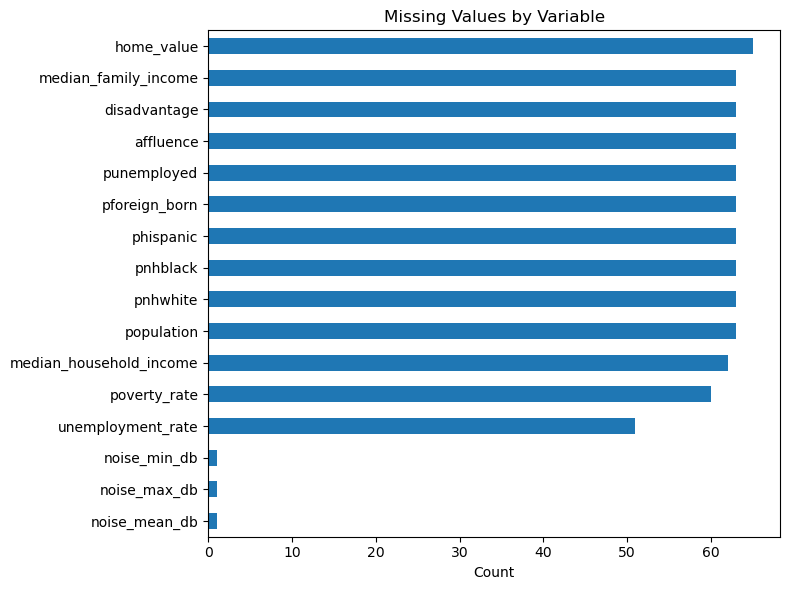

In [8]:
missing[missing > 0].sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Missing Values by Variable")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

## 3. Distribution of Key Variables

We examine the distributions of:

- Noise exposure
- Home value
- Median household income
- Poverty rate

These visualizations help identify:

- Skewness
- Outliers
- Data quality issues

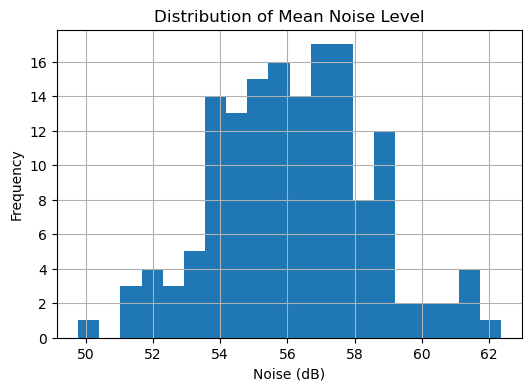

In [10]:
plt.figure(figsize=(6,4))

master["noise_mean_db"].hist(bins=20)

plt.title("Distribution of Mean Noise Level")
plt.xlabel("Noise (dB)")
plt.ylabel("Frequency")

plt.show()

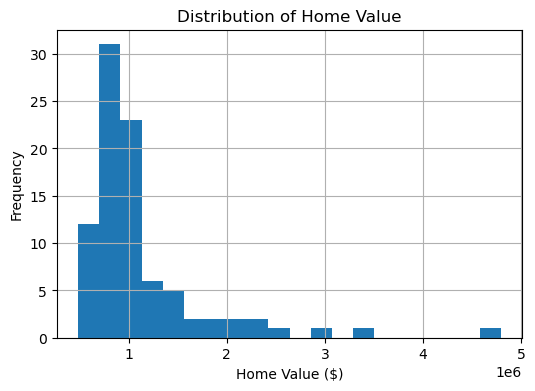

In [11]:
plt.figure(figsize=(6,4))

master["home_value"].dropna().hist(bins=20)

plt.title("Distribution of Home Value")
plt.xlabel("Home Value ($)")
plt.ylabel("Frequency")

plt.show()

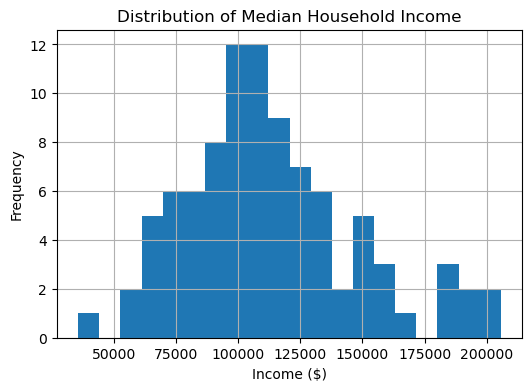

In [12]:
plt.figure(figsize=(6,4))

master["median_household_income"].dropna().hist(bins=20)

plt.title("Distribution of Median Household Income")
plt.xlabel("Income ($)")
plt.ylabel("Frequency")

plt.show()

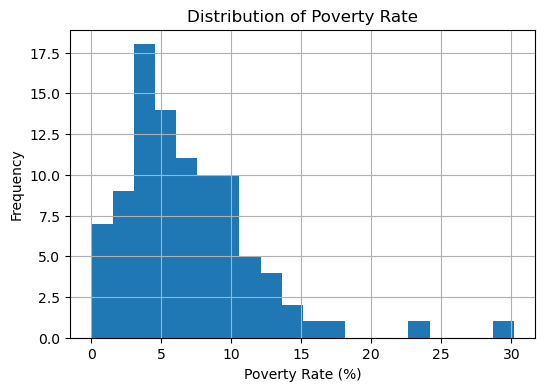

In [13]:
plt.figure(figsize=(6,4))

master["poverty_rate"].dropna().hist(bins=20)

plt.title("Distribution of Poverty Rate")
plt.xlabel("Poverty Rate (%)")
plt.ylabel("Frequency")

plt.show()

## 4. Relationships with Noise Exposure

Next, we examine whether transportation noise is associated with:

- Housing value
- Household income
- Poverty rate

Scatterplots provide a first visual assessment of these relationships.

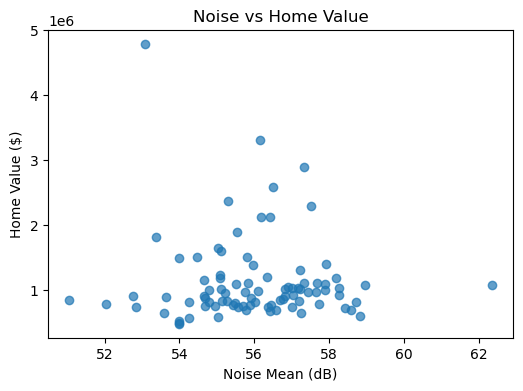

In [15]:
plt.figure(figsize=(6,4))

plt.scatter(
    master["noise_mean_db"],
    master["home_value"],
    alpha=0.7
)

plt.xlabel("Noise Mean (dB)")
plt.ylabel("Home Value ($)")
plt.title("Noise vs Home Value")

plt.show()

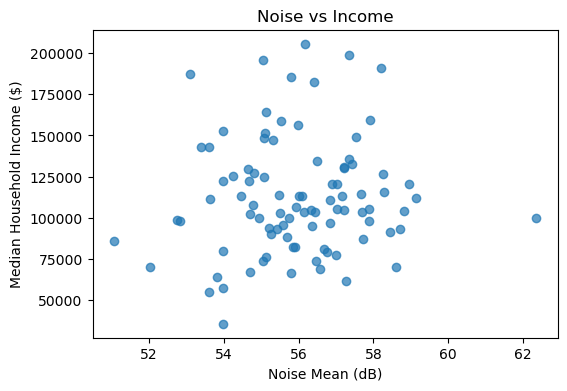

In [16]:
plt.figure(figsize=(6,4))

plt.scatter(
    master["noise_mean_db"],
    master["median_household_income"],
    alpha=0.7
)

plt.xlabel("Noise Mean (dB)")
plt.ylabel("Median Household Income ($)")
plt.title("Noise vs Income")

plt.show()

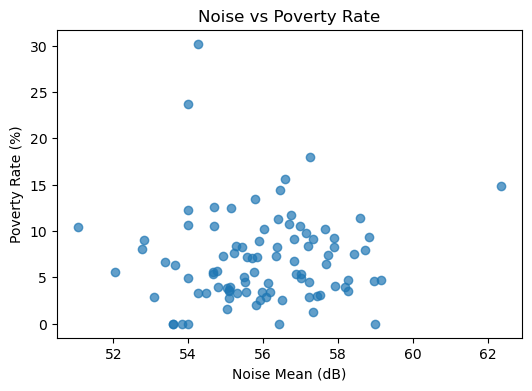

In [17]:
plt.figure(figsize=(6,4))

plt.scatter(
    master["noise_mean_db"],
    master["poverty_rate"],
    alpha=0.7
)

plt.xlabel("Noise Mean (dB)")
plt.ylabel("Poverty Rate (%)")
plt.title("Noise vs Poverty Rate")

plt.show()

## 5. Correlation Analysis

Correlation analysis helps identify linear relationships between variables.

Strong correlations may indicate:

- Important predictors for modeling
- Potential multicollinearity issues

In [19]:
corr = master.corr(numeric_only=True)

corr

,zcta,noise_mean_db,noise_max_db,noise_min_db,median_household_income,unemployment_rate,population,pnhwhite,pnhblack,phispanic,pforeign_born,punemployed,affluence,disadvantage,median_family_income,home_value,poverty_rate
zcta,1.000000,0.211847,0.161385,-0.197691,-0.020414,-0.156983,0.020722,0.069130,-0.021747,-0.149862,0.026967,-0.076205,0.118142,-0.043252,0.017217,0.114936,-0.014234
noise_mean_db,0.211847,1.000000,0.871409,-0.219610,0.074172,-0.141495,-0.042334,-0.155519,0.019045,0.111091,0.165081,-0.145058,0.123013,-0.114554,0.024304,-0.041170,0.031238
noise_max_db,0.161385,0.871409,1.000000,-0.262232,0.155210,-0.049337,-0.050939,-0.034518,-0.024055,-0.002953,0.115680,-0.070540,0.221154,-0.111160,0.133310,0.040051,-0.086030
noise_min_db,-0.197691,-0.219610,-0.262232,1.000000,-0.092441,0.175617,0.150534,-0.227050,0.202958,0.250498,0.059001,0.133630,-0.149938,0.037728,-0.137755,-0.099693,0.007822
median_household_income,-0.020414,0.074172,0.155210,-0.092441,1.000000,0.233997,-0.134429,0.250266,-0.312618,-0.427392,-0.066214,-0.277241,0.803735,-0.759880,0.866964,0.616888,-0.562820
unemployment_rate,-0.156983,-0.141495,-0.049337,0.175617,0.233997,1.000000,0.415336,-0.232330,0.183870,0.123586,0.273789,-0.155209,0.216099,-0.195019,0.033121,-0.148790,0.002829
population,0.020722,-0.042334,-0.050939,0.150534,-0.134429,0.415336,1.000000,-0.533647,0.348706,0.425805,0.613269,0.079134,-0.189849,0.167527,-0.259260,-0.243755,0.127247
pnhwhite,0.069130,-0.155519,-0.034518,-0.227050,0.250266,-0.232330,-0.533647,1.000000,-0.534439,-0.853314,-0.800161,-0.217229,0.465303,-0.304175,0.445928,0.358767,-0.360104
pnhblack,-0.021747,0.019045,-0.024055,0.202958,-0.312618,0.183870,0.348706,-0.534439,1.000000,0.361620,0.274553,0.194162,-0.372237,0.377460,-0.415099,-0.321355,0.290189
phispanic,-0.149862,0.111091,-0.002953,0.250498,-0.427392,0.123586,0.425805,-0.853314,0.361620,1.000000,0.593294,0.291845,-0.657685,0.431897,-0.582193,-0.389836,0.430241


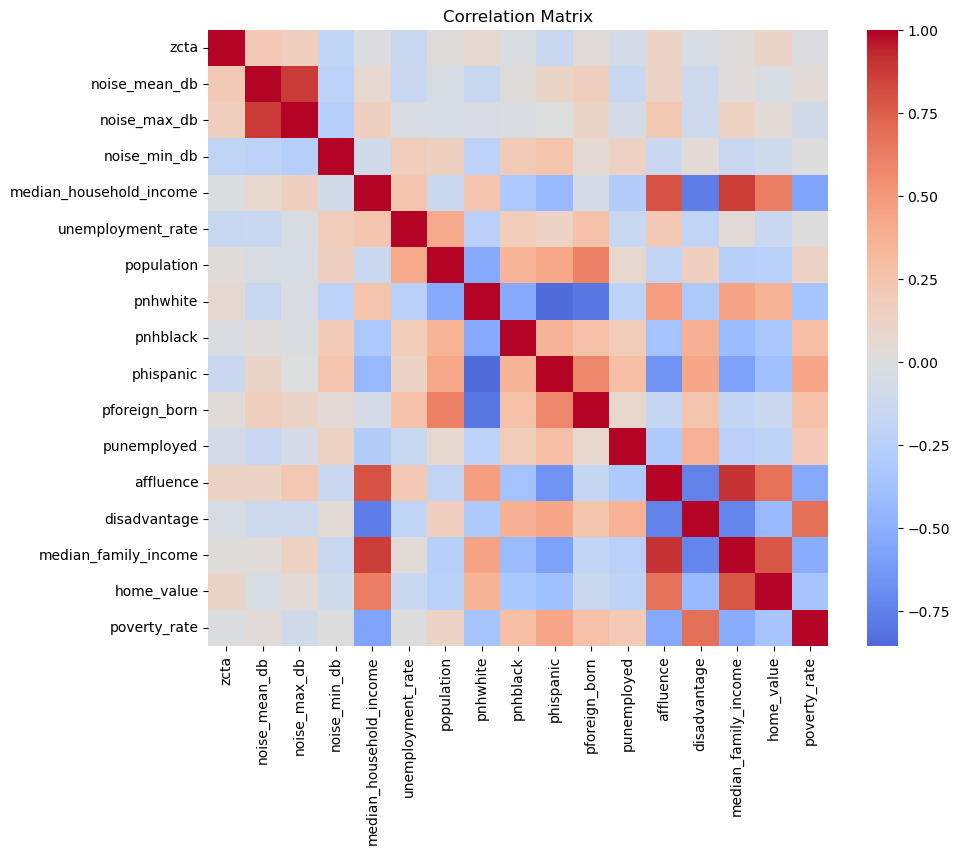

In [21]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

### Correlations with Transportation Noise

To better understand which variables are associated with transportation noise exposure, we examine the correlations between `noise_mean_db` and all other variables.

Most socioeconomic variables show only weak correlations with transportation noise, suggesting that transportation noise alone may not strongly explain variation in socioeconomic conditions across San Diego County.

In [23]:
corr["noise_mean_db"].sort_values(
    ascending=False
)

noise_mean_db              1.000000
noise_max_db               0.871409
zcta                       0.211847
pforeign_born              0.165081
affluence                  0.123013
phispanic                  0.111091
median_household_income    0.074172
poverty_rate               0.031238
median_family_income       0.024304
pnhblack                   0.019045
home_value                -0.041170
population                -0.042334
disadvantage              -0.114554
unemployment_rate         -0.141495
punemployed               -0.145058
pnhwhite                  -0.155519
noise_min_db              -0.219610
Name: noise_mean_db, dtype: float64

## Preliminary Findings

Based on the exploratory analysis, several important patterns emerged.

### Transportation Noise Distribution

The distribution of mean transportation noise appears approximately centered around 56 dB, with most ZCTAs falling between 54 and 58 dB. A small number of areas experience substantially higher noise exposure above 60 dB.

### Housing and Socioeconomic Variables

Home values are strongly right-skewed, with a few ZCTAs exhibiting extremely high housing prices. Median household income is more evenly distributed, while poverty rates are concentrated at relatively low levels with several high-poverty outliers.

### Noise and Socioeconomic Conditions

The scatterplots suggest that transportation noise has only weak relationships with home value, income, and poverty rate. No strong linear pattern is immediately visible. This indicates that transportation noise alone may not explain socioeconomic variation across San Diego County.

### Missing Data Issues

Several socioeconomic variables contain substantial missing data. Many ACS-derived variables are missing for approximately 40% of ZCTAs. Appropriate handling of missing observations will be necessary during the modeling stage.

### Variables for Modeling

Potential predictors for future modeling include:

- noise_mean_db
- median_household_income
- poverty_rate
- affluence
- disadvantage
- pforeign_born
- unemployment_rate

The correlation matrix suggests that some socioeconomic variables are highly correlated with one another, which may create multicollinearity issues in regression models. Variable selection techniques may therefore be useful during model development.